# Regression Basis Comparison: Laguerre vs Gaussian RBF

Compare Laguerre polynomial and Gaussian radial basis function (RBF) regression bases for the LSM American put pricer under the LLH stochastic volatility model.

**Gaussian RBF design:**
- Centers placed at quantile grid of ITM spot values (adaptive per time step)
- Bandwidth via Silverman's rule: $h = 1.06 \cdot s \cdot n^{-1/5}$
- Basis: $\Phi_{ik} = \exp\!\bigl(-|x_i - c_k|^2 / (2h^2)\bigr)$

In [1]:
import sys
sys.path.insert(0, '../src')
import testing as tst

PARAMS_T1 = dict(r=0.01, kappa=5, nu=0.2, lam=0.9, eta=0.01, rho=-0.2,
                 sigma0=0.15, theta0=0.18)
PARAMS_T2 = dict(r=0.01, kappa=4.9394, nu=0.3943, lam=0.3115, eta=0.4112,
                 rho=0.1691, sigma0=0.2924, theta0=0.1319)
K = 100.0
S0_GRID = [85.0, 90.0, 100.0, 110.0, 115.0]
MONEYNESS = ['Deep ITM', 'ITM', 'ATM', 'OTM', 'Deep OTM']
N_PATHS = 10_000
T, N_STEPS_MC, SEED = 1.0, 52, 42
LLH_PARAMS = dict(phi_max=300.0, n_phi=513, n_steps_rk4=128)

CONFIGS = [
    ('Laguerre', 'laguerre', 3, 1e-5),
    ('Gaussian', 'gaussian', 15, 1e-4),
]

## 1. Moneyness Comparison

In [2]:
print('=== Table 1 ===')
df_t1 = tst.basis_comparison_grid(PARAMS_T1, K, S0_GRID, MONEYNESS,
                                  T, N_STEPS_MC, N_PATHS, SEED, LLH_PARAMS, CONFIGS)
print('\n=== Table 2 ===')
df_t2 = tst.basis_comparison_grid(PARAMS_T2, K, S0_GRID, MONEYNESS,
                                  T, N_STEPS_MC, N_PATHS, SEED, LLH_PARAMS, CONFIGS)
tst.format_basis_table(df_t1)

=== Table 1 ===
  Deep ITM: done
  ITM: done
  ATM: done
  OTM: done
  Deep OTM: done

=== Table 2 ===


/home/ramiuness/Documents/study/umontreal/myCourses/amerOptionsPricing/project/notebooks/../src/priceModels.py:342: RuntimeWarning: invalid value encountered in log
  x  = np.log(S_vec)                 # (N,)


  Deep ITM: done
  ITM: done
  ATM: done
  OTM: done
  Deep OTM: done


,S0,Lag Plain,Lag SE,Gau Plain,Gau SE,Lag CV-LLH,Lag CV SE,Gau CV-LLH,Gau CV SE,Lag VR,Gau VR
Moneyness,,,,,,,,,,,
Deep ITM,85,26.6763,0.2284,25.0454,0.2005,27.0568,0.0092,27.0563,0.0092,613.5,473.3
ITM,90,24.1508,0.2239,23.4828,0.2096,24.6380,0.0089,24.6372,0.0089,626.2,548.7
ATM,100,19.9161,0.2151,19.8480,0.2119,20.4156,0.0083,20.4140,0.0083,671.2,651.6
OTM,110,16.4398,0.2038,16.4035,0.2024,16.9161,0.0076,16.9159,0.0076,721.5,711.7
Deep OTM,115,14.9078,0.1986,14.9266,0.1967,15.4033,0.0072,15.4027,0.0072,756.3,742.0


In [3]:
tst.format_basis_table(df_t2)

,S0,Lag Plain,Lag SE,Gau Plain,Gau SE,Lag CV-LLH,Lag CV SE,Gau CV-LLH,Gau CV SE,Lag VR,Gau VR
Moneyness,,,,,,,,,,,
Deep ITM,85,20.0303,0.1775,19.8039,0.1573,20.8773,0.0251,20.8890,0.0251,50.1,39.4
ITM,90,16.8338,0.1754,16.6488,0.1587,17.7818,0.0245,17.7907,0.0245,51.3,42.0
ATM,100,11.6760,0.1676,11.4992,0.1553,12.7065,0.0221,12.7151,0.0221,57.4,49.2
OTM,110,8.1632,0.1541,8.1100,0.1476,9.0757,0.0190,9.0807,0.0190,66.0,60.5
Deep OTM,115,6.8890,0.1472,6.8706,0.1422,7.7126,0.0174,7.7168,0.0174,71.9,67.0


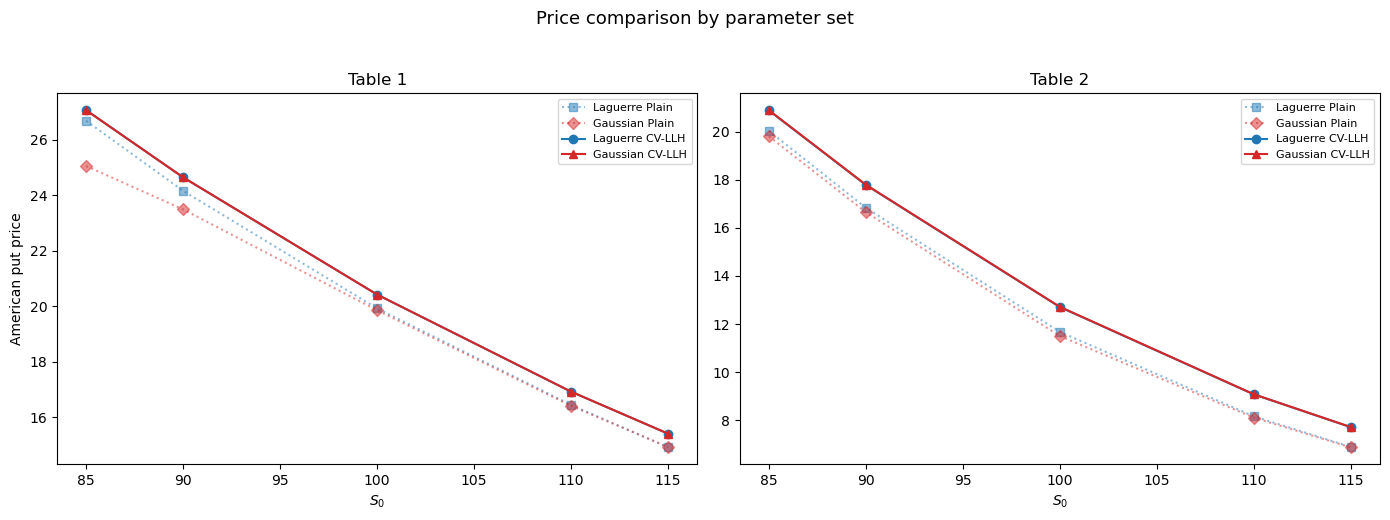

In [4]:
tst.plot_basis_table([df_t1, df_t2], ['Table 1', 'Table 2'])

## 2. Sensitivity to Gaussian basis_order

  M=3: Plain=19.7533, CV-LLH=20.4147
  M=5: Plain=19.7586, CV-LLH=20.4148
  M=10: Plain=19.8145, CV-LLH=20.4145
  M=15: Plain=19.8480, CV-LLH=20.4140
  M=20: Plain=19.8882, CV-LLH=20.4146
  M=30: Plain=19.8361, CV-LLH=20.4145


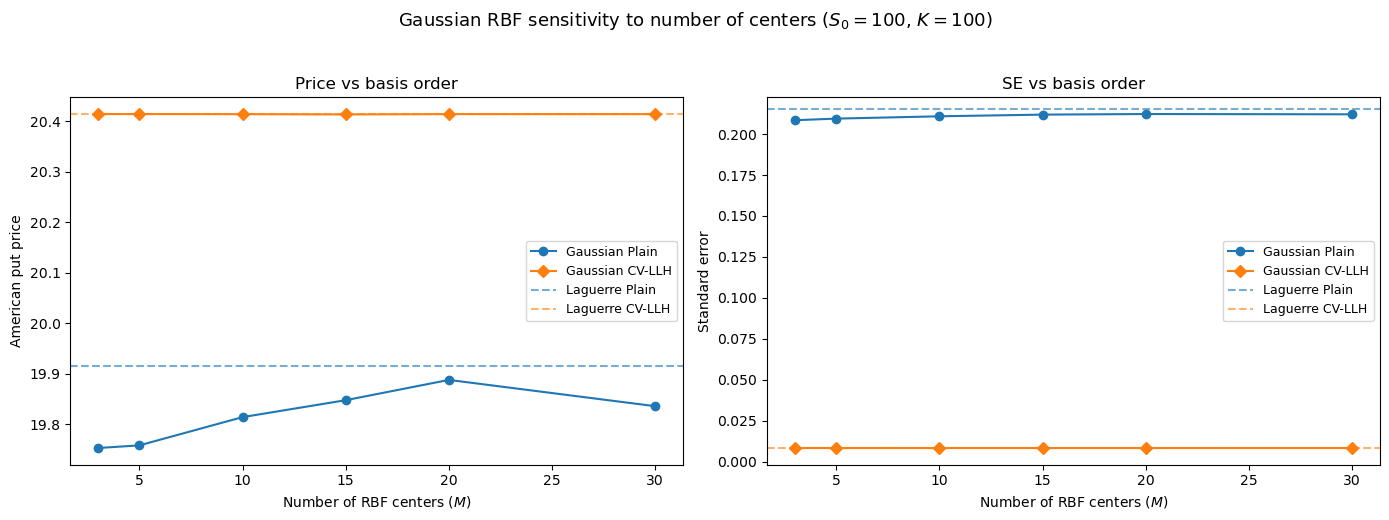

In [5]:
sens_df, lag_p, lag_cv = tst.basis_sensitivity(
    PARAMS_T1, 100.0, K, T, N_STEPS_MC, N_PATHS, SEED, LLH_PARAMS,
    orders=[3, 5, 10, 15, 20, 30])
tst.plot_basis_sensitivity(sens_df, lag_p, lag_cv, S0=100.0, K=K)

## 3. Price and VR Comparison

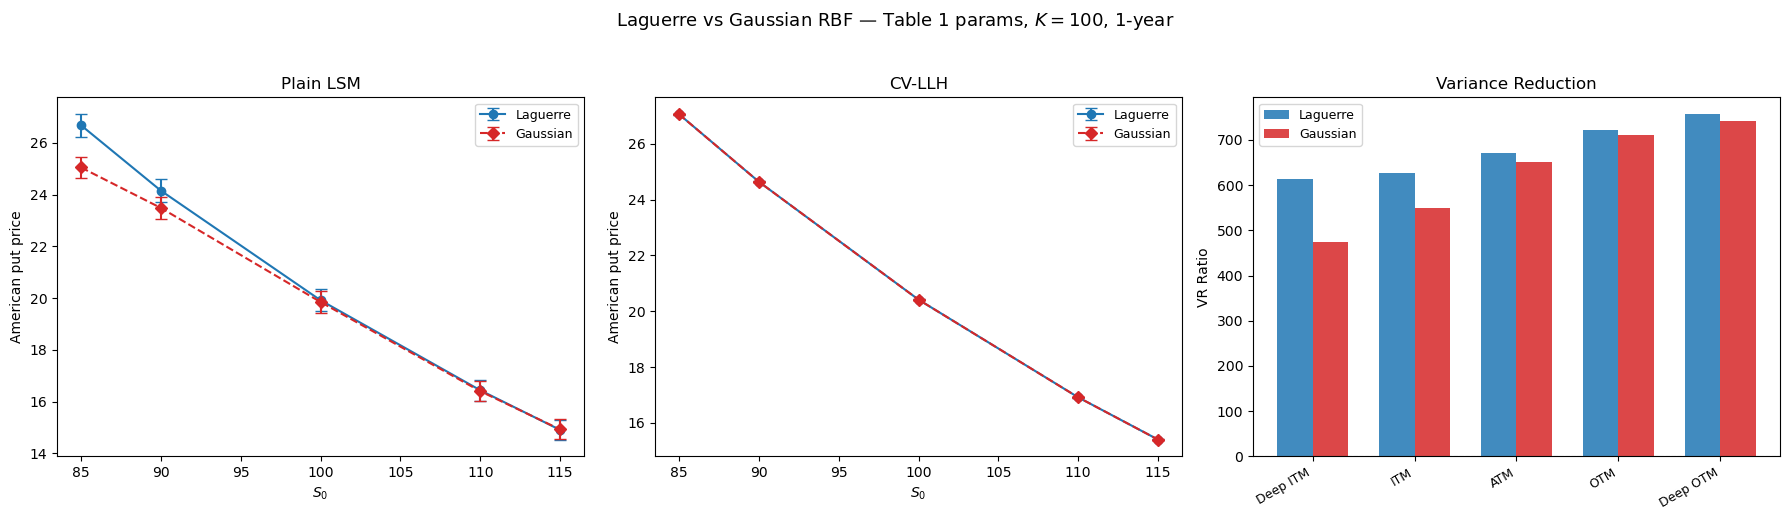

In [6]:
tst.plot_basis_comparison(df_t1, MONEYNESS,
    title_suffix=' — Table 1 params, $K=100$, 1-year')

## 4. Price Comparison by Moneyness Range

Three panels: All, ITM-only ($S_0 \leq K$), OTM-only ($S_0 \geq K$). Shows CV-LLH prices with plain LSM as faded reference.

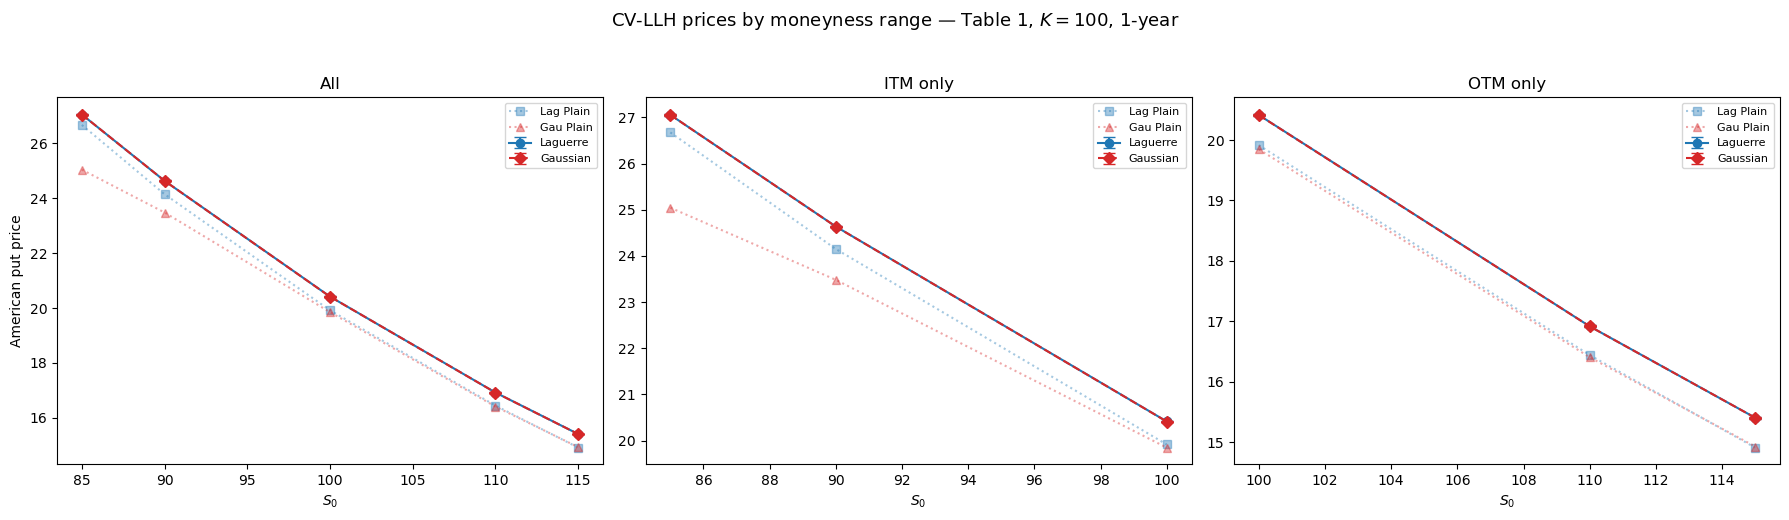

In [7]:
tst.plot_basis_by_moneyness(df_t1, title_suffix=' — Table 1, $K=100$, 1-year')

## 5. Bias Assessment

The LSM estimator has a known **downward bias** (sub-optimal exercise boundary). Control variates change the exercise decision, potentially shifting the bias. To assess this empirically, we run $R=20$ independent replications at increasing $N$ and compare each estimator's mean against a high-$N$ reference.

If the bias is significant, the "Bias / SE" plot will show a persistent non-zero level that doesn't shrink with $N$ (bias is $O(1/J)$ where $J$ is the basis order, not $O(1/\sqrt{N})$ like the SE).

In [ ]:
BIAS_CONFIGS = [
    ('Laguerre Plain',   'laguerre',  3, 1e-5, False),
    ('Laguerre CV-LLH',  'laguerre',  3, 1e-5, True),
    ('Gaussian Plain',   'gaussian', 15, 1e-4, False),
    ('Gaussian CV-LLH',  'gaussian', 15, 1e-4, True),
]

bias_df, ref_prices = tst.bias_convergence(
    PARAMS_T1, S0=100.0, K=K, T=T, n_steps_mc=N_STEPS_MC, seed=SEED,
    N_values=[1_000, 5_000, 10_000, 50_000],
    R=20, llh_params=LLH_PARAMS, configs=BIAS_CONFIGS)

print("\nReference prices (at N=50,000):")
for name, p in ref_prices.items():
    print(f"  {name:22s}: {p:.4f}")

tst.plot_bias_convergence(bias_df, ref_prices, S0=100.0, K=K)

  Laguerre Plain         N=   1000: mean=20.3486
  Laguerre Plain         N=   5000: mean=20.3656
  Laguerre Plain         N=  10000: mean=20.3029
  Laguerre Plain         N=  50000: mean=20.2441
  Laguerre CV-LLH        N=   1000: mean=20.4094
  Laguerre CV-LLH        N=   5000: mean=20.4118
  Laguerre CV-LLH        N=  10000: mean=20.4076
